# Análisis dinámico numérico del doble péndulo

En este notebook se realiza el análisis dinámico del doble péndulo utilizando el Robotics Toolbox de Python. Se implementan simulaciones, cálculos de dinámica inversa, y controladores para estudiar el comportamiento del sistema.

In [ ]:
# Para correr en Colab
%pip install roboticstoolbox-python
%pip install numpy==1.26.4 --force-reinstall

# Nota importante: da error porque un montón de bibliotecas de Colab dependen de numpy 2, 
# pero como no se utilizan no importa. 
#
# Cuando termina de ejecutarse la celda, pide reiniciar el kernel (aparece un botón bien evidente)
# Luego de reiniciar correr las celdas siguientes

## Importaciones y configuración

Se cargan las bibliotecas necesarias para trabajar con robótica y análisis numérico.

In [1]:
# Hacemos todas las importaciones necesarias
# numpy para manejar array y algebra lineal
import numpy as np
import scipy as sc
# la funcionalidad específica de robótica está en el toolbox
import roboticstoolbox as rtb
# spatialmath tiene define los grupos de transformaciones especiales: rotación SO3 y eculideo SE3
import spatialmath as sm
import spatialmath.base.symbolic as sym
import matplotlib.pyplot as plt  

## Definición del robot doble péndulo

Se define el modelo cinemático y dinámico del doble péndulo utilizando parámetros DH (Denavit-Hartenberg). Se especifican masas, momentos de inercia, centros de masa y fricción para cada eslabón.

In [2]:
# Preparo el modelo de un doble péndulo
dp =rtb.DHRobot(
    [
        rtb.RevoluteDH(a=200e-3,m=1,
                r=np.array([-100, 0, 0]) * 1e-3,
                I=np.array([0,0,0,0,0,0,0,0,1e-3]),
                B=0, G=1),                
        rtb.RevoluteDH(a=200e-3,m=1,
                r=np.array([-100, 0, 0]) * 1e-3,
                I=np.array([0,0,0,0,0,0,0,0,1e-4]),
                B=1*0, G=1),                                
    ], 
    gravity = np.array([0, -9.8, 0]), # Ojo con el signo, la gravedad va hacia abajo con signo positivo
    name = "dp")

qr = np.array([-np.pi/2,0])
qz = np.zeros((2,))

print(dp)
print(dp.dynamics())

DHRobot: dp, 2 joints (RR), dynamics, standard DH parameters
┌─────┬────┬─────┬──────┐
│ θⱼ  │ dⱼ │ aⱼ  │  ⍺ⱼ  │
├─────┼────┼─────┼──────┤
│  q1 │  0 │ 0.2 │ 0.0° │
│  q2 │  0 │ 0.2 │ 0.0° │
└─────┴────┴─────┴──────┘

┌──┬──┐
└──┴──┘

┌───────┬────┬──────────────┬─────────────────────────────┬────┬────┬────────┬────┐
│   j   │ m  │      r       │              I              │ Jm │ B  │   Tc   │ G  │
├───────┼────┼──────────────┼─────────────────────────────┼────┼────┼────────┼────┤
│ link1 │  1 │ -0.1,  0,  0 │  0,  0,  0.001,  0,  0,  0  │  0 │  0 │  0,  0 │  1 │
│ link2 │  1 │ -0.1,  0,  0 │  0,  0,  0.0001,  0,  0,  0 │  0 │  0 │  0,  0 │  1 │
└───────┴────┴──────────────┴─────────────────────────────┴────┴────┴────────┴────┘

None


## Dinámica inversa

Se calcula el torque necesario aplicando el algoritmo de dinámica inversa (RNE - Recursive Newton-Euler). Se muestran también las matrices de inercia (M), Coriolis (C) y gravedad (G).

In [3]:
# Dinámica inversa 
# de la docu:
# rne(q, qd=None, qdd=None, gravity=None, fext=None, base_wrench=False)[source]
#    Inverse dynamics
#    Parameters
#            q (ndarray(n)) – Joint coordinates
#            qd (ndarray(n)) – Joint velocity
#            qdd (ndarray(n)) – The joint accelerations of the robot
#            gravity (ndarray(6)) – Gravitational acceleration to override robot’s gravity value
#            fext (ndarray(6)) – Specify wrench acting on the end-effector 

q = qz
qd = np.zeros((2,))
qdd = np.zeros((2,))
tau = dp.rne(q, qd, qdd)
print(f"Torque para mantener el doble péndulo en q={q} -> tau={tau}")

print("M=\n", dp.inertia(q))
print("C=\n",dp.coriolis(q, qd))
print("G=\n",dp.gravload(q))


Torque para mantener el doble péndulo en q=[0. 0.] -> tau=[3.92 0.98]
M=
 [[0.1011 0.0301]
 [0.0301 0.0101]]
C=
 [[0. 0.]
 [0. 0.]]
G=
 [3.92 0.98]


## Simulación de dinámica directa sin control

Se realiza la integración numérica de las ecuaciones del movimiento del doble péndulo bajo gravedad, sin aplicar torques externos. Se visualizan las trayectorias articulares y el movimiento en el espacio de operación.

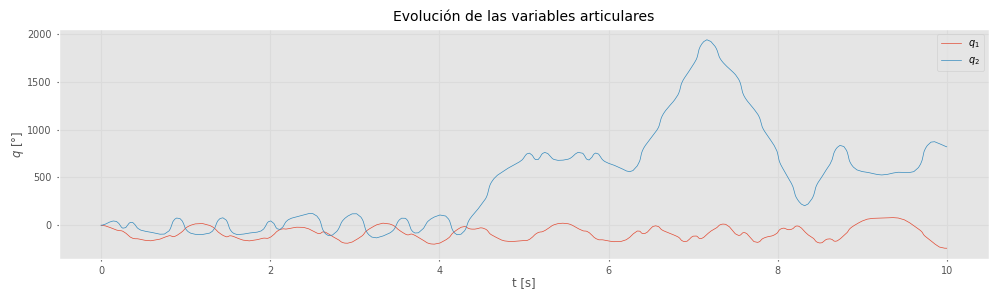

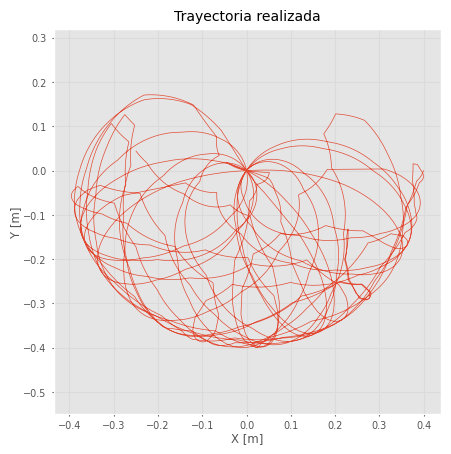

In [4]:
# Simulación del sistema dinámico
# De la docu:
# fdyn(T, q0, torque=None, torque_args={}, qd0=None, solver='RK45', solver_args={}, dt=None, progress=False) 
# Integrate forward dynamics
#    Parameters
#            T (float) – integration time
#            q0 (array_like) – initial joint coordinates
#            qd0 (array_like) – initial joint velocities, assumed zero if not given
#            torque – a function that computes torque as a function of time

q_ini = np.array([0,0])

#tg = dp.nofriction(coulomb=False, viscous=False).fdyn(5, q_ini,qd0=np.zeros((2,)),dt=1e-3)
tg = dp.fdyn(10, q_ini,qd0=np.zeros((2,)),dt=1e-3)

plt.figure(figsize=(10,3))
plt.plot(tg.t.reshape(tg.t.shape[0],1) ,tg.q*180/np.pi)
plt.xlabel('t [s]')
plt.ylabel(r'$q$ [°]')
plt.legend([r'$q_1$',r'$q_2$'])
plt.title('Evolución de las variables articulares')
plt.tight_layout()
plt.show()

trayectoria = dp.fkine(tg.q)
X = trayectoria.t[:,0]
Y = trayectoria.t[:,1]
Z = trayectoria.t[:,2]

plt.figure(figsize=(5,5))
plt.plot(X,Y)
plt.xlabel('X [m]')
plt.ylabel('Y [m]')
plt.title('Trayectoria realizada')
plt.axis('equal')
plt.show()


In [6]:
# Muestro la animación del robot

def dp_animate(q, Ts=0.1, trail=False, interval=None):
    """
    Animación de doble péndulo a partir de coordenadas articulares

    Parámetros:
    - q: array (nq, N) trayectoria articular
    - Ts: paso de tiempo (s)
    - trail: True para dejar traza del extremo
    - interval: ms entre frames (default = Ts*1000)

    Retorna:
    - HTML para visualizar en notebook
    """
    from matplotlib.animation import FuncAnimation
    from IPython.display import HTML

    plt.rcParams["animation.html"] = "html5"

    N = q.shape[0]

    # --- calcular posiciones ---
    xy_codo = np.zeros((N, 3))
    xy_tool = np.zeros((N, 3))

    for i in range(N):
        q_i = q[i,:]

        T = dp.fkine_all(q_i)
        
        T_codo = T[1]
        T_tool = T[2]
        xy_codo[i, :] = T_codo.t
        xy_tool[i, :] = T_tool.t

    # base
    x0, y0 = 0.0, 0.0

    x1, y1 = xy_codo[:, 0], xy_codo[:, 1]
    x2, y2 = xy_tool[:, 0], xy_tool[:, 1]

    # --- figura ---
    fig, ax = plt.subplots()
    ax.set_aspect('equal')

    all_x = np.concatenate(([x0], x1, x2))
    all_y = np.concatenate(([y0], y1, y2))
    margin = 0.2

    ax.set_xlim(all_x.min() - margin, all_x.max() + margin)
    ax.set_ylim(all_y.min() - margin, all_y.max() + margin)

    line, = ax.plot([], [], 'o-', lw=2)
    trail_line = None

    if trail:
        trail_line, = ax.plot([], [], '-', alpha=0.3)

    # --- animación ---
    def init():
        line.set_data([], [])
        if trail_line:
            trail_line.set_data([], [])
            return line, trail_line
        return (line,)

    def update(i):
        xs = [x0, x1[i], x2[i]]
        ys = [y0, y1[i], y2[i]]

        line.set_data(xs, ys)

        if trail_line:
            trail_line.set_data(x2[:i], y2[:i])
            return line, trail_line

        return (line,)

    if interval is None:
        interval = Ts * 1000

    ani = FuncAnimation(fig, update,
                        frames=N,
                        init_func=init,
                        interval=interval,
                        blit=True)

    plt.close(fig)

    return HTML(ani.to_html5_video())

dp_animate(tg.q[0:-1:20],Ts=1e-3*20,trail=True)

## Equilibrio dinámico con compensación de gravedad

Se aplica un torque compensador que cancela el efecto de la gravedad, manteniendo el doble péndulo en equilibrio.

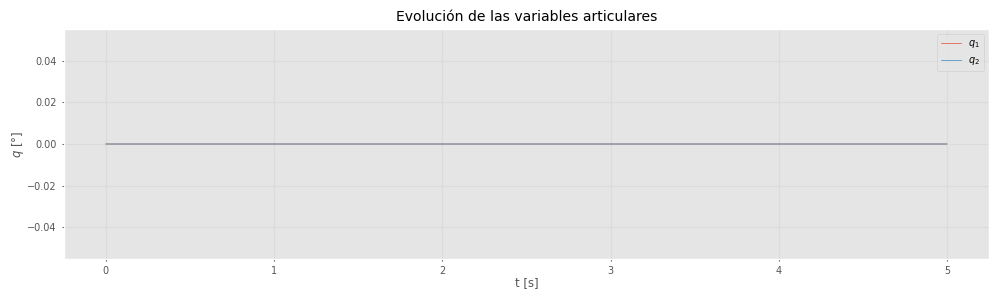

In [37]:
# Repito la simulación pero aplicando un torque que compense el peso propio
def torque_sosten(robot, t, q, qd):
  return np.array(dp.gravload(qz))

tg = dp.nofriction().fdyn(5, qz,Q=torque_sosten,qd0=np.zeros((2,)),dt=1e-3)

plt.figure(figsize=(10,3))
plt.plot(tg.t,tg.q*180/np.pi)
plt.xlabel('t [s]')
plt.ylabel(r'$q$ [°]')
plt.legend([r'$q_1$',r'$q_2$'])
plt.title('Evolución de las variables articulares')
plt.tight_layout()
plt.show()


## Control proporcional-derivativo (PD) - Respuesta al escalón

Se implementa un controlador PD que intenta llevar el doble péndulo a una posición deseada fija. Se analiza la respuesta transitoria del sistema controlado.

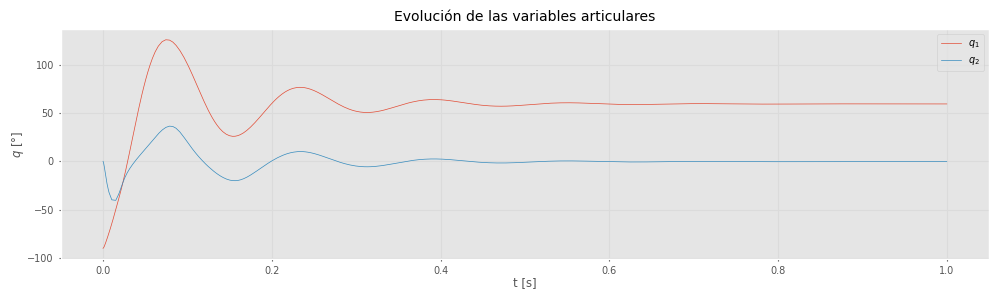

In [38]:
def controlPD(robot, t, q, qd, q_deseado, Kp, Kd):
    return Kp.dot(q_deseado - q) - Kd.dot(qd)

Kp = np.diag([200, 100]) 
Kd = np.diag([2, 1]) 

q_deseado = np.array([np.pi/3,0])

tg = dp.nofriction(True,True).fdyn(1, qr, Q=controlPD, Q_args={'q_deseado':q_deseado, 'Kp':Kp, 'Kd':Kd},dt=1e-4) 

plt.figure(figsize=(10,3))
plt.plot(tg.t,tg.q*180/np.pi)
plt.xlabel('t [s]')
plt.ylabel(r'$q$ [°]')
plt.legend([r'$q_1$',r'$q_2$'])
plt.title('Evolución de las variables articulares')
plt.tight_layout()
plt.show()

In [33]:
dp_animate(tg.q[0:-1:20],Ts=1e-4*20,trail=True)

## Control PD - Seguimiento de trayectoria

Se implementa un controlador PD que hace seguir al doble péndulo una trayectoria trapezoidal prescrita en ambas articulaciones. Se grafica tanto la trayectoria deseada como la realizada, y el error de seguimiento.

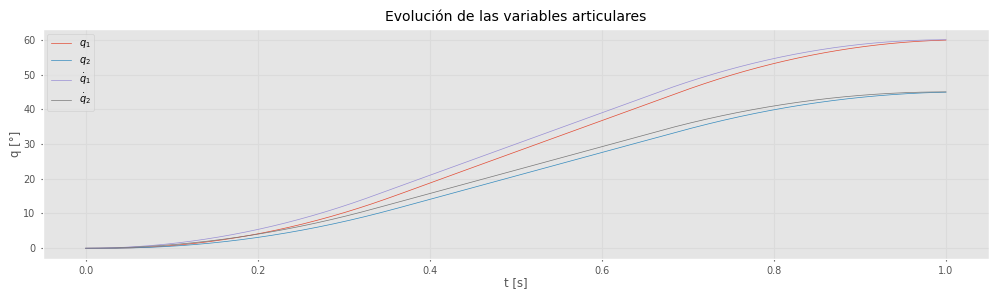

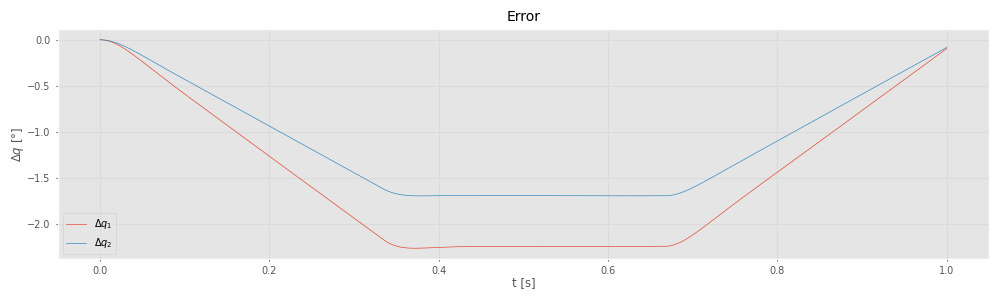

In [51]:
# Evaluo la respuesta a una trayectoria
dt = 1e-4
n_samples = 10000
Tspan = n_samples * dt
t = np.arange(0,Tspan,dt)

q_des = rtb.mtraj(rtb.trapezoidal, qz, [np.pi/3,np.pi/4], t).q

def controlPD(robot, t, q, qd, q_deseado, Kp, Kd):
    idx = np.round(t/dt).astype(int)
    if idx>=n_samples:
      idx=-1
    q_ref = q_deseado[idx,:]
    # problema: el integrador toma mas muestras? ---> paso variable ??
    return Kp.dot(q_ref - q) - Kd.dot(qd) + robot.gravload(q)

Kp = np.diag([400, 200]) 
Kd = np.diag([10, 5]) 

tg = dp.nofriction(True,True).fdyn(1, qz, Q=controlPD, Q_args={'q_deseado':q_des, 'Kp':Kp, 'Kd':Kd},dt=1e-4) 

plt.figure(figsize=(10,3))
plt.plot(tg.t,tg.q*180/np.pi)
plt.plot(tg.t,q_des*180/np.pi)
plt.xlabel('t [s]')
plt.ylabel('q [°]')
plt.legend([r'$q_1$',r'$q_2$',r'$\dot{q}_1$',r'$\dot{q}_2$'])
plt.title('Evolución de las variables articulares')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,3))
plt.plot(tg.t,(tg.q-q_des)*180/np.pi)
plt.xlabel('t [s]')
plt.ylabel(r'$\Delta q$ [°]')
plt.legend([r'$\Delta q_1$',r'$\Delta q_2$'])
plt.title('Error')
plt.tight_layout()
plt.show()


In [52]:
dp_animate(tg.q[0:-1:20],Ts=dt*20,trail=True)

## Control PD DIGITAL - Seguimiento de trayectoria


In [40]:
from scipy.integrate import solve_ivp

def f(t, x, tau):
    n = len(x)//2
    q = x[:n]
    qd = x[n:]

    qdd = dp.accel(q,qd,tau)

    return np.hstack((qd, qdd))

100%|██████████| 1000/1000 [00:02<00:00, 390.82it/s]


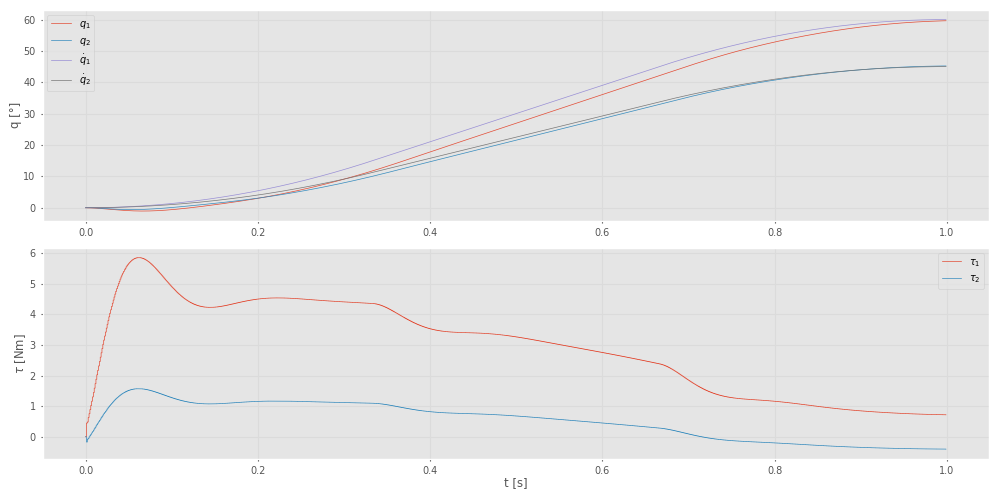

In [59]:
from tqdm import tqdm
# Evaluo la respuesta a una trayectoria

# Configuro la base de tiempo de la simulación
dt = 1e-3
n_samples = 1000
Tspan = n_samples * dt
t = np.arange(0,Tspan,dt)

# Ganancias del controlador
Kp = np.diag([200, 100]) 
Kd = np.diag([5, 1])

# Condición inicial
q = qz
qd = np.zeros_like(q)
x = np.hstack((q,qd))

# Calculo offline las referencias
q_des = rtb.mtraj(rtb.trapezoidal, qz, [np.pi/3,np.pi/4], t).q

# Defino vectores para almacenar datos 
q_samples = np.zeros((n_samples,len(q)))
qd_samples = np.zeros((n_samples,len(q)))
tau_samples = np.zeros((n_samples,len(q)))

for i in tqdm(range(n_samples)):
   # Obtengo la referencia para el instante actual
   q_ref = q_des[i]
   # Calculo la acción de control para el instante de tiempo actual
   tau = Kp.dot(q_ref - x[:2]) - Kd.dot(x[2:]) #+ dp.gravload(x[:2])   
   
   # Integración de tiempo continuo en un paso con tau constante
   sol = solve_ivp(
        lambda t, x_: f(t, x_, tau),
        [0, dt],
        x,
        method='RK45',
        t_eval=[dt],   # solo me interesa el final
        rtol=1e-6,
        atol=1e-9
    )

   # Actualizo los estados
   x = sol.y[:,-1]

   # Almaceno resultados para graficar luego
   q_samples[i,:] = x[:2]
   qd_samples[i,:] = x[2:]
   tau_samples[i,:] = tau

plt.figure(figsize=(10,5))
plt.subplot(2,1,1)
plt.plot(t,q_samples*180/np.pi)
plt.plot(t,q_des*180/np.pi)
plt.ylabel('q [°]')
plt.legend([r'$q_1$',r'$q_2$',r'$\dot{q}_1$',r'$\dot{q}_2$'])
plt.subplot(2,1,2)
plt.step(t,tau_samples,where='post')
plt.legend([r'$\tau_1$',r'$\tau_2$'])
plt.ylabel(r'$\tau$ [Nm]')
plt.xlabel('t [s]')
plt.tight_layout()
plt.show()

In [48]:
dp_animate(q_samples[0:-1:20],Ts=dt*20,trail=True)